GitHub + Drive setup

In [34]:
from google.colab import drive
drive.mount("/content/drive")

!rm -rf /content/ML-2026-1R
!git clone -b SJ https://github.com/Heineeee/ML-2026-1R.git /content/ML-2026-1R

%cd /content/ML-2026-1R
!pwd
!ls -lh

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
Cloning into '/content/ML-2026-1R'...
fatal: Unable to read current working directory: No such file or directory
[Errno 2] No such file or directory: '/content/ML-2026-1R'
/content/ML-2026-1R
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
pwd: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
total 0


Import + path config

In [35]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True

print("device:", device)

REPO_ROOT = "/content/ML-2026-1R"

PROJECT_DRIVE = "/content/drive/MyDrive/vtac_project"
DATA_DIR = f"{PROJECT_DRIVE}/data/processed"
OUT_DIR = f"{PROJECT_DRIVE}/outputs/proposed_cvae_concat"

os.makedirs(OUT_DIR, exist_ok=True)

TRAIN_PT = f"{DATA_DIR}/train_10s.pt"
VAL_PT = f"{DATA_DIR}/val_10s.pt"
TEST_PT = f"{DATA_DIR}/test_10s.pt"

print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR)

!ls -lh "$DATA_DIR"

device: cuda
DATA_DIR: /content/drive/MyDrive/vtac_project/data/processed
OUT_DIR: /content/drive/MyDrive/vtac_project/outputs/proposed_cvae_concat
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
total 193M
-rw------- 1 root root  19M May 26 12:27 test_10s.pt
-rw------- 1 root root 155M May 26 12:27 train_10s.pt
-rw------- 1 root root  19M May 26 12:27 val_10s.pt


Load preprocessed data

In [36]:
def safe_torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def load_split(path):
    data = safe_torch_load(path)

    X = data["X"].float()               # [N, 4, 2500]
    y = data["y"].long()                # [N]
    m = data["m_channel"].float()       # [N, 4]

    print("\n", path)
    print("X:", tuple(X.shape))
    print("y:", tuple(y.shape))
    print("m:", tuple(m.shape))
    print("channels:", data["channels"])
    print("window:", data["window_sec"])
    print("label counts [False, True]:", torch.bincount(y, minlength=2).tolist())
    print("channel availability:", m.sum(dim=0).long().tolist())

    return X, y, m, data


X_train, y_train, m_train, train_meta = load_split(TRAIN_PT)
X_val, y_val, m_val, val_meta = load_split(VAL_PT)
X_test, y_test, m_test, test_meta = load_split(TEST_PT)


 /content/drive/MyDrive/vtac_project/data/processed/train_10s.pt
X: (4018, 4, 2500)
y: (4018,)
m: (4018, 4)
channels: ['ECG1', 'ECG2', 'PPG', 'ABP']
window: [-10, 0]
label counts [False, True]: [2863, 1155]
channel availability: [4018, 4018, 3731, 1461]

 /content/drive/MyDrive/vtac_project/data/processed/val_10s.pt
X: (493, 4, 2500)
y: (493,)
m: (493, 4)
channels: ['ECG1', 'ECG2', 'PPG', 'ABP']
window: [-10, 0]
label counts [False, True]: [353, 140]
channel availability: [493, 493, 459, 181]

 /content/drive/MyDrive/vtac_project/data/processed/test_10s.pt
X: (482, 4, 2500)
y: (482,)
m: (482, 4)
channels: ['ECG1', 'ECG2', 'PPG', 'ABP']
window: [-10, 0]
label counts [False, True]: [345, 137]
channel availability: [482, 482, 448, 183]


Dataset + condition

In [37]:
C_DIM = 5
LATENT_DIM = 128
BATCH_SIZE = 64
SEQ_LEN = 2500

CHANNELS = ["ECG1", "ECG2", "PPG", "ABP"]


def make_condition(y, m):
    """
    c = [label, m_ECG1, m_ECG2, m_PPG, m_ABP]
    """
    return torch.cat(
        [
            y.float().unsqueeze(1),
            m.float(),
        ],
        dim=1,
    )


c_train = make_condition(y_train, m_train)
c_val = make_condition(y_val, m_val)
c_test = make_condition(y_test, m_test)

print("c_train:", c_train.shape)
print("c_val:", c_val.shape)
print("c_test:", c_test.shape)

train_ds = TensorDataset(X_train, c_train, m_train)
val_ds = TensorDataset(X_val, c_val, m_val)

# True alarm oversampling
class_count = torch.bincount(y_train, minlength=2)
class_weight = 1.0 / class_count.float()
sample_weight = class_weight[y_train]

sampler = WeightedRandomSampler(
    weights=sample_weight,
    num_samples=len(sample_weight),
    replacement=True,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("train false:", int((y_train == 0).sum()))
print("train true :", int((y_train == 1).sum()))

c_train: torch.Size([4018, 5])
c_val: torch.Size([493, 5])
c_test: torch.Size([482, 5])
train false: 2863
train true : 1155


Model: 기존 구조 기반 Multi-Branch Concat CVAE

In [38]:
class ConvBranchEncoder(nn.Module):
    def __init__(
        self,
        in_wave_channels,
        c_dim,
        hidden_channels=(32, 64, 128),
        out_dim=256,
        seq_len=2500,
        norm_groups=8,
    ):
        super().__init__()

        self.in_wave_channels = in_wave_channels
        self.c_dim = c_dim
        self.seq_len = seq_len

        in_channels = in_wave_channels + c_dim

        def gn(ch):
            g = min(norm_groups, ch)
            while ch % g != 0:
                g -= 1
            return nn.GroupNorm(g, ch)

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, hidden_channels[0], kernel_size=9, stride=2, padding=4),
            gn(hidden_channels[0]),
            nn.SiLU(),

            nn.Conv1d(hidden_channels[0], hidden_channels[1], kernel_size=9, stride=2, padding=4),
            gn(hidden_channels[1]),
            nn.SiLU(),

            nn.Conv1d(hidden_channels[1], hidden_channels[2], kernel_size=7, stride=2, padding=3),
            gn(hidden_channels[2]),
            nn.SiLU(),

            nn.Conv1d(hidden_channels[2], hidden_channels[2], kernel_size=7, stride=1, padding=3),
            gn(hidden_channels[2]),
            nn.SiLU(),
        )

        # infer conv output size
        with torch.no_grad():
            dummy_x = torch.zeros(1, in_wave_channels, seq_len)
            dummy_c = torch.zeros(1, c_dim, seq_len)
            dummy = torch.cat([dummy_x, dummy_c], dim=1)
            h = self.conv(dummy)
            self.flat_dim = h.shape[1] * h.shape[2]

        # 기존 잘 되던 방식: temporal feature map flatten
        self.proj = nn.Sequential(
            nn.Linear(self.flat_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.SiLU(),
        )

    def forward(self, x_branch, c):
        """
        x_branch: [B, branch_channels, T]
        c: [B, c_dim]
        """
        B, _, T = x_branch.shape

        c_expand = c.unsqueeze(-1).expand(B, self.c_dim, T)
        h = torch.cat([x_branch, c_expand], dim=1)

        h = self.conv(h)
        h = h.flatten(start_dim=1)
        h = self.proj(h)

        return h


class MultiBranchConcatCVAE(nn.Module):
    def __init__(
        self,
        x_channels=4,
        c_dim=5,
        latent_dim=128,
        seq_len=2500,
        branch_dim=256,
        fusion_dim=512,
        norm_groups=8,
    ):
        super().__init__()

        self.x_channels = x_channels
        self.c_dim = c_dim
        self.latent_dim = latent_dim
        self.seq_len = seq_len
        self.branch_dim = branch_dim

        # Branch encoders
        self.ecg_encoder = ConvBranchEncoder(
            in_wave_channels=2,
            c_dim=c_dim,
            out_dim=branch_dim,
            seq_len=seq_len,
            norm_groups=norm_groups,
        )

        self.ppg_encoder = ConvBranchEncoder(
            in_wave_channels=1,
            c_dim=c_dim,
            out_dim=branch_dim,
            seq_len=seq_len,
            norm_groups=norm_groups,
        )

        self.abp_encoder = ConvBranchEncoder(
            in_wave_channels=1,
            c_dim=c_dim,
            out_dim=branch_dim,
            seq_len=seq_len,
            norm_groups=norm_groups,
        )

        # Concat fusion
        # 나중에 여기를 CrossAttentionFusion으로 교체
        self.fusion = nn.Sequential(
            nn.Linear(3 * branch_dim + c_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.SiLU(),

            nn.Linear(fusion_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.SiLU(),
        )

        self.fc_mu = nn.Linear(fusion_dim, latent_dim)
        self.fc_logvar = nn.Linear(fusion_dim, latent_dim)

        # Decoder: no BatchNorm
        self.dec_len = seq_len // 4      # 2500 -> 625 -> upsample x4
        self.dec_channels = 128
        self.dec_feat_dim = self.dec_channels * self.dec_len

        self.fc_dec = nn.Sequential(
            nn.Linear(latent_dim + c_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.SiLU(),

            nn.Linear(fusion_dim, self.dec_feat_dim),
            nn.SiLU(),
        )

        self.decoder = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=7, padding=3),
            nn.SiLU(),

            nn.Upsample(scale_factor=2, mode="linear", align_corners=False),
            nn.Conv1d(128, 64, kernel_size=7, padding=3),
            nn.SiLU(),

            nn.Upsample(scale_factor=2, mode="linear", align_corners=False),
            nn.Conv1d(64, 32, kernel_size=7, padding=3),
            nn.SiLU(),

            nn.Conv1d(32, x_channels, kernel_size=9, padding=4),
        )

    def _match_length(self, x, target_len):
        cur_len = x.shape[-1]

        if cur_len == target_len:
            return x

        if cur_len > target_len:
            return x[..., :target_len]

        pad_len = target_len - cur_len
        return F.pad(x, (0, pad_len))

    def _get_branch_gates(self, c):
        """
        c = [label, m_ECG1, m_ECG2, m_PPG, m_ABP]
        """
        if c.size(1) < 5:
            B = c.size(0)
            one = torch.ones(B, 1, device=c.device, dtype=c.dtype)
            return one, one, one

        m_ecg1 = c[:, 1:2]
        m_ecg2 = c[:, 2:3]
        m_ppg = c[:, 3:4]
        m_abp = c[:, 4:5]

        # ECG1/ECG2 중 하나라도 있으면 ECG branch 사용
        g_ecg = torch.clamp(m_ecg1 + m_ecg2, 0.0, 1.0)
        g_ppg = m_ppg
        g_abp = m_abp

        return g_ecg, g_ppg, g_abp

    def encode(self, x, c):
        """
        x: [B, 4, T]
        c: [B, 5]
        """
        x_ecg = x[:, 0:2, :]
        x_ppg = x[:, 2:3, :]
        x_abp = x[:, 3:4, :]

        g_ecg, g_ppg, g_abp = self._get_branch_gates(c)

        h_ecg = self.ecg_encoder(x_ecg, c) * g_ecg
        h_ppg = self.ppg_encoder(x_ppg, c) * g_ppg
        h_abp = self.abp_encoder(x_abp, c) * g_abp

        h = torch.cat([h_ecg, h_ppg, h_abp, c], dim=1)
        h = self.fusion(h)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c, m_channel=None):
        h = torch.cat([z, c], dim=1)
        h = self.fc_dec(h)
        h = h.view(z.size(0), self.dec_channels, self.dec_len)

        x_hat = self.decoder(h)
        x_hat = self._match_length(x_hat, self.seq_len)

        if m_channel is not None:
            x_hat = x_hat * m_channel.unsqueeze(-1)

        return x_hat

    def forward(self, x, c, m_channel=None):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z, c, m_channel=m_channel)

        return x_hat, mu, logvar

    @torch.no_grad()
    def reconstruct(self, x, c, m_channel=None, use_mean=True):
        self.eval()

        mu, logvar = self.encode(x, c)

        if use_mean:
            z = mu
        else:
            z = self.reparameterize(mu, logvar)

        return self.decode(z, c, m_channel=m_channel)

    @torch.no_grad()
    def sample_prior(self, c, n=None, z_scale=0.7, m_channel=None):
        self.eval()

        if n is None:
            n = c.size(0)

        if c.size(0) == 1 and n > 1:
            c = c.expand(n, -1)

        assert c.size(0) == n, "c batch size must match n."

        z = torch.randn(
            n,
            self.latent_dim,
            device=c.device,
            dtype=c.dtype,
        ) * z_scale

        return self.decode(z, c, m_channel=m_channel)

Masked losses

In [39]:
def masked_recon_loss(x, x_hat, m_channel, eps=1e-8):
    """
    x, x_hat: [B, 4, T]
    m_channel: [B, 4]
    """
    mask = m_channel.to(dtype=x.dtype).unsqueeze(-1)

    mse = (x - x_hat) ** 2
    mse = mse * mask

    denom = mask.sum() * x.shape[-1] + eps
    return mse.sum() / denom


def masked_derivative_loss(x, x_hat, m_channel, eps=1e-8):
    """
    sharp transition / peak 보존
    """
    mask = m_channel.to(dtype=x.dtype).unsqueeze(-1)

    dx = x[:, :, 1:] - x[:, :, :-1]
    dx_hat = x_hat[:, :, 1:] - x_hat[:, :, :-1]

    mse = (dx - dx_hat) ** 2
    mse = mse * mask

    denom = mask.sum() * dx.shape[-1] + eps
    return mse.sum() / denom


def masked_std_loss(x, x_hat, m_channel, eps=1e-8):
    """
    flat waveform collapse 방지
    """
    mask = m_channel.to(dtype=x.dtype)

    x_std = x.std(dim=-1)
    x_hat_std = x_hat.std(dim=-1)

    loss = (x_std - x_hat_std) ** 2
    loss = loss * mask

    denom = mask.sum() + eps
    return loss.sum() / denom


def kl_divergence(mu, logvar):
    logvar = torch.clamp(logvar, min=-10.0, max=10.0)

    kl = -0.5 * torch.mean(
        torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    )

    return kl


def kl_beta_anneal(epoch, beta_max=1e-4, warmup_epochs=20):
    if warmup_epochs <= 0:
        return beta_max

    ratio = min(1.0, epoch / warmup_epochs)
    return beta_max * ratio


def cvae_loss(
    x,
    x_hat,
    mu,
    logvar,
    m_channel,
    beta=1e-4,
    gamma_deriv=0.5,
    gamma_std=0.1,
):
    recon = masked_recon_loss(x, x_hat, m_channel)
    deriv = masked_derivative_loss(x, x_hat, m_channel)
    std = masked_std_loss(x, x_hat, m_channel)
    kl = kl_divergence(mu, logvar)

    loss = recon + gamma_deriv * deriv + gamma_std * std + beta * kl

    logs = {
        "loss": loss.detach(),
        "recon": recon.detach(),
        "deriv": deriv.detach(),
        "std": std.detach(),
        "kl": kl.detach(),
    }

    return loss, logs

Train functions

In [40]:
def unpack_batch(batch, device):
    x, c, m_channel = batch

    x = x.to(device).float()
    c = c.to(device).float()
    m_channel = m_channel.to(device).float()

    return x, c, m_channel


def run_one_epoch(
    model,
    loader,
    optimizer=None,
    device="cuda",
    epoch=1,
    beta_max=1e-4,
    warmup_epochs=20,
    gamma_deriv=0.5,
    gamma_std=0.1,
    grad_clip=1.0,
):
    is_train = optimizer is not None

    model.train() if is_train else model.eval()

    beta = kl_beta_anneal(
        epoch=epoch,
        beta_max=beta_max,
        warmup_epochs=warmup_epochs,
    )

    total_loss = 0.0
    total_recon = 0.0
    total_deriv = 0.0
    total_std = 0.0
    total_kl = 0.0
    n_batch = 0

    for batch in loader:
        x, c, m_channel = unpack_batch(batch, device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

            x_hat, mu, logvar = model(x, c, m_channel=m_channel)

            loss, logs = cvae_loss(
                x=x,
                x_hat=x_hat,
                mu=mu,
                logvar=logvar,
                m_channel=m_channel,
                beta=beta,
                gamma_deriv=gamma_deriv,
                gamma_std=gamma_std,
            )

            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

        else:
            with torch.no_grad():
                x_hat, mu, logvar = model(x, c, m_channel=m_channel)

                loss, logs = cvae_loss(
                    x=x,
                    x_hat=x_hat,
                    mu=mu,
                    logvar=logvar,
                    m_channel=m_channel,
                    beta=beta,
                    gamma_deriv=gamma_deriv,
                    gamma_std=gamma_std,
                )

        total_loss += logs["loss"].item()
        total_recon += logs["recon"].item()
        total_deriv += logs["deriv"].item()
        total_std += logs["std"].item()
        total_kl += logs["kl"].item()
        n_batch += 1

    return {
        "loss": total_loss / n_batch,
        "recon": total_recon / n_batch,
        "deriv": total_deriv / n_batch,
        "std": total_std / n_batch,
        "kl": total_kl / n_batch,
        "beta": beta,
    }


def train_cvae(
    model,
    train_loader,
    val_loader=None,
    device="cuda",
    epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    beta_max=1e-4,
    warmup_epochs=20,
    gamma_deriv=0.5,
    gamma_std=0.1,
    grad_clip=1.0,
    save_path=None,
):
    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    history = {
        "train": [],
        "val": [],
    }

    best_val_loss = float("inf")
    best_epoch = -1

    for epoch in range(1, epochs + 1):
        train_logs = run_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=device,
            epoch=epoch,
            beta_max=beta_max,
            warmup_epochs=warmup_epochs,
            gamma_deriv=gamma_deriv,
            gamma_std=gamma_std,
            grad_clip=grad_clip,
        )

        history["train"].append(train_logs)

        val_logs = None

        if val_loader is not None:
            val_logs = run_one_epoch(
                model=model,
                loader=val_loader,
                optimizer=None,
                device=device,
                epoch=epoch,
                beta_max=beta_max,
                warmup_epochs=warmup_epochs,
                gamma_deriv=gamma_deriv,
                gamma_std=gamma_std,
                grad_clip=grad_clip,
            )

            history["val"].append(val_logs)
            current_val = val_logs["loss"]

            if current_val < best_val_loss:
                best_val_loss = current_val
                best_epoch = epoch

                if save_path is not None:
                    torch.save(
                        {
                            "model_state_dict": model.state_dict(),
                            "history": history,
                            "epoch": epoch,
                            "val_loss": best_val_loss,
                            "config": {
                                "model": "MultiBranchConcatCVAE",
                                "latent_dim": model.latent_dim,
                                "seq_len": model.seq_len,
                                "branch_dim": model.branch_dim,
                                "c_dim": model.c_dim,
                                "beta_max": beta_max,
                                "warmup_epochs": warmup_epochs,
                                "gamma_deriv": gamma_deriv,
                                "gamma_std": gamma_std,
                            },
                        },
                        save_path,
                    )

        if epoch == 1 or epoch % 5 == 0:
            msg = (
                f"Epoch {epoch:03d} | "
                f"train loss={train_logs['loss']:.4f}, "
                f"recon={train_logs['recon']:.4f}, "
                f"deriv={train_logs['deriv']:.4f}, "
                f"std={train_logs['std']:.4f}, "
                f"kl={train_logs['kl']:.4f}, "
                f"beta={train_logs['beta']:.2e}"
            )

            if val_logs is not None:
                msg += (
                    f" | val loss={val_logs['loss']:.4f}, "
                    f"recon={val_logs['recon']:.4f}, "
                    f"deriv={val_logs['deriv']:.4f}, "
                    f"std={val_logs['std']:.4f}, "
                    f"kl={val_logs['kl']:.4f}"
                )

            print(msg)

    print("best epoch:", best_epoch)
    print("best val loss:", best_val_loss)

    return model, history

Train

In [41]:
model = MultiBranchConcatCVAE(
    x_channels=4,
    c_dim=C_DIM,
    latent_dim=LATENT_DIM,
    seq_len=SEQ_LEN,
    branch_dim=256,
    fusion_dim=512,
).to(device)

SAVE_PATH = f"{OUT_DIR}/multibranch_concat_cvae_best.pt"

model, history = train_cvae(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    beta_max=1e-4,
    warmup_epochs=20,
    gamma_deriv=0.5,
    gamma_std=0.1,
    grad_clip=1.0,
    save_path=SAVE_PATH,
)

print("saved:", SAVE_PATH)

Epoch 001 | train loss=0.9958, recon=0.9189, deriv=0.0240, std=0.6455, kl=82.8721, beta=5.00e-06 | val loss=0.9232, recon=0.8579, deriv=0.0263, std=0.5131, kl=187.3821
Epoch 005 | train loss=0.6381, recon=0.5994, deriv=0.0220, std=0.2027, kl=298.0408, beta=2.50e-05 | val loss=0.7720, recon=0.7294, deriv=0.0267, std=0.2149, kl=307.8587
Epoch 010 | train loss=0.3297, recon=0.3014, deriv=0.0153, std=0.0574, kl=296.8412, beta=5.00e-05 | val loss=0.7858, recon=0.7420, deriv=0.0282, std=0.1489, kl=296.4251
Epoch 015 | train loss=0.1829, recon=0.1551, deriv=0.0103, std=0.0192, kl=276.4453, beta=7.50e-05 | val loss=0.8141, recon=0.7665, deriv=0.0288, std=0.1264, kl=274.8083
Epoch 020 | train loss=0.1306, recon=0.1000, deriv=0.0080, std=0.0091, kl=256.5852, beta=1.00e-04 | val loss=0.8293, recon=0.7765, deriv=0.0291, std=0.1284, kl=254.1673
Epoch 025 | train loss=0.0980, recon=0.0692, deriv=0.0062, std=0.0050, kl=251.2734, beta=1.00e-04 | val loss=0.8229, recon=0.7697, deriv=0.0290, std=0.1343,

Reconstruction *check*

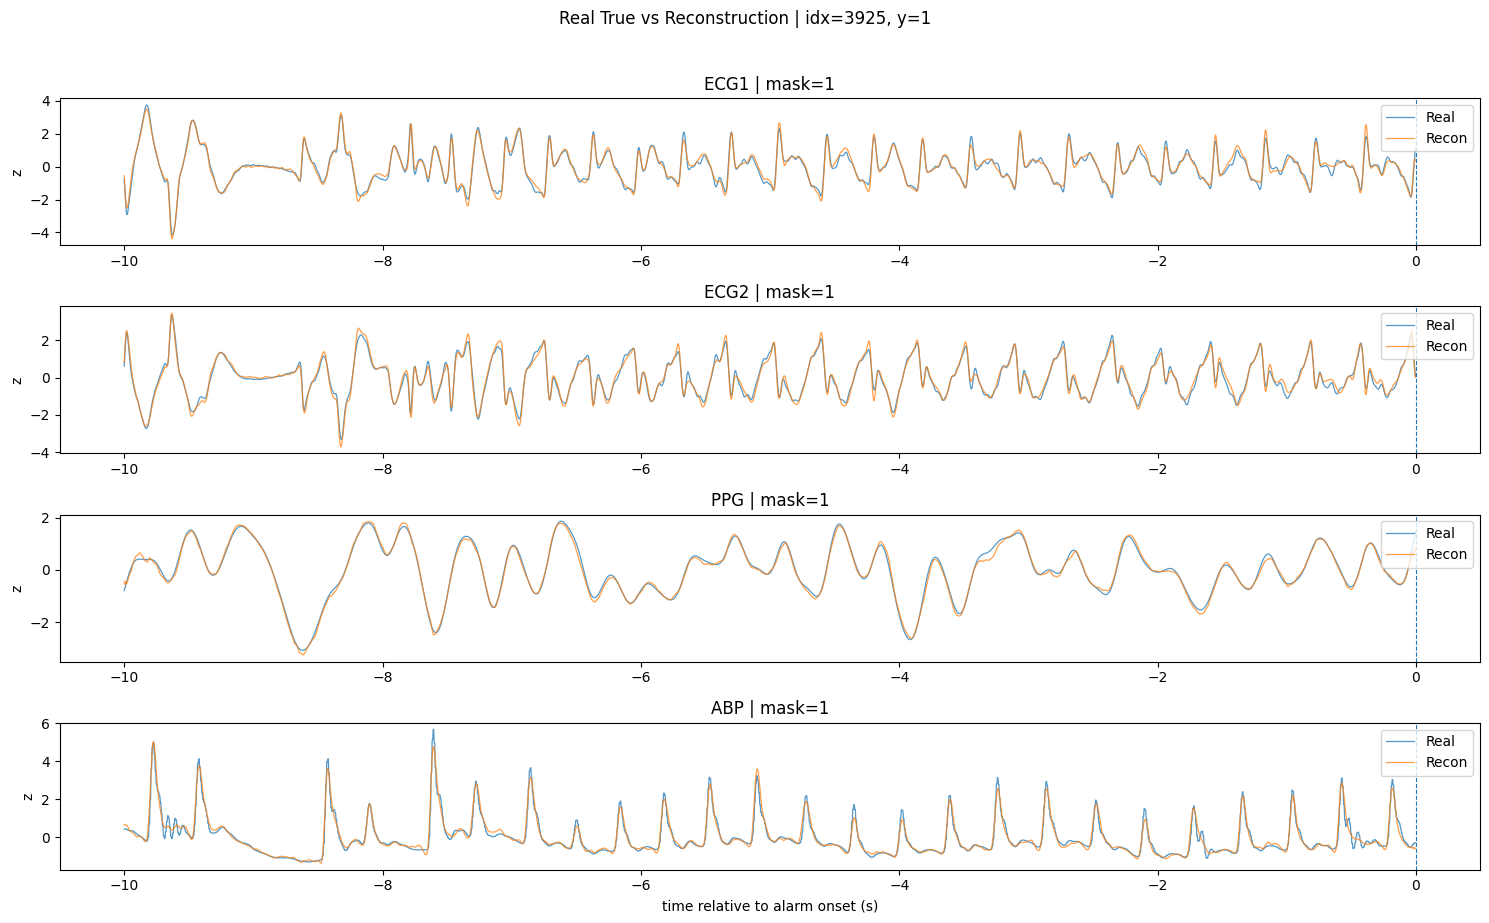

idx: 3925
x std: 1.0000499486923218
x_hat std: 1.0107734203338623


3925

In [42]:
@torch.no_grad()
def plot_real_vs_recon(
    model,
    X_real,
    y_real,
    m_real,
    idx=None,
    true_only=True,
    fs=250,
    channel_names=("ECG1", "ECG2", "PPG", "ABP"),
):
    model.eval()

    if idx is None:
        y_np = y_real.cpu().numpy()
        if true_only:
            candidates = np.where(y_np == 1)[0]
        else:
            candidates = np.arange(len(y_np))
        idx = int(np.random.choice(candidates))

    x = X_real[idx:idx+1].to(device)
    y = y_real[idx:idx+1].to(device)
    m = m_real[idx:idx+1].to(device)
    c = torch.cat([y.float().unsqueeze(1), m.float()], dim=1)

    x_hat = model.reconstruct(x, c, m_channel=m, use_mean=True)

    x_np = x[0].detach().cpu().numpy()
    xhat_np = x_hat[0].detach().cpu().numpy()
    m_np = m[0].detach().cpu().numpy().astype(int)

    t = np.arange(x_np.shape[1]) / fs - 10.0

    plt.figure(figsize=(15, 9))

    for i, ch in enumerate(channel_names):
        plt.subplot(4, 1, i + 1)

        if m_np[i] == 1:
            plt.plot(t, x_np[i], linewidth=0.9, alpha=0.75, label="Real")
            plt.plot(t, xhat_np[i], linewidth=0.9, alpha=0.75, label="Recon")

        plt.axvline(0, linestyle="--", linewidth=0.8)
        plt.title(f"{ch} | mask={m_np[i]}")
        plt.ylabel("z")
        plt.legend(loc="upper right")

    plt.xlabel("time relative to alarm onset (s)")
    plt.suptitle(f"Real True vs Reconstruction | idx={idx}, y={int(y.item())}", y=1.02)
    plt.tight_layout()
    plt.show()

    print("idx:", idx)
    print("x std:", x.std().item())
    print("x_hat std:", x_hat.std().item())

    return idx


plot_real_vs_recon(
    model=model,
    X_real=X_train,
    y_real=y_train,
    m_real=m_train,
    true_only=True,
)

Generate true alarm samples

In [43]:
@torch.no_grad()
def generate_multibranch_cvae_true_samples(
    model,
    real_true_masks,
    n_samples=500,
    z_scale=0.7,
    batch_size=128,
    device="cuda",
):
    """
    condition c = [1, sampled real channel mask]
    """
    model.eval()

    if isinstance(real_true_masks, np.ndarray):
        real_true_masks = torch.tensor(real_true_masks, dtype=torch.float32)

    real_true_masks = real_true_masks.float()

    rng = np.random.default_rng(SEED)
    sampled_idx = rng.choice(
        np.arange(len(real_true_masks)),
        size=n_samples,
        replace=True,
    )

    sampled_masks = real_true_masks[sampled_idx].float()

    c_true = torch.cat(
        [
            torch.ones(n_samples, 1),
            sampled_masks,
        ],
        dim=1,
    )

    outs = []

    for s in range(0, n_samples, batch_size):
        cb = c_true[s:s + batch_size].to(device)
        mb = sampled_masks[s:s + batch_size].to(device)

        xb = model.sample_prior(
            c=cb,
            n=cb.size(0),
            z_scale=z_scale,
            m_channel=mb,
        )

        xb = xb * mb.unsqueeze(-1)
        outs.append(xb.cpu())

    X_gen = torch.cat(outs, dim=0)

    return X_gen, sampled_masks


n_false = int((y_train == 0).sum())
n_true = int((y_train == 1).sum())
n_to_generate = n_false - n_true

m_real_true = m_train[y_train == 1]

print("false:", n_false)
print("true:", n_true)
print("generate:", n_to_generate)
print("true mask pool:", m_real_true.shape)

X_cvae_true, m_cvae_true = generate_multibranch_cvae_true_samples(
    model=model,
    real_true_masks=m_real_true,
    n_samples=n_to_generate,
    z_scale=0.7,
    batch_size=128,
    device=device,
)

y_cvae_true = torch.ones(len(X_cvae_true), dtype=torch.long)

print("X_cvae_true:", X_cvae_true.shape)
print("y_cvae_true:", y_cvae_true.shape)
print("m_cvae_true:", m_cvae_true.shape)
print("CVAE sample std:", X_cvae_true.std().item())

syn_data = {
    "X_syn": X_cvae_true,
    "y_syn": y_cvae_true,
    "m_syn": m_cvae_true,
    "method": "multibranch_concat_cvae_refactored",
    "channels": CHANNELS,
    "window_sec": [-10, 0],
    "sampling_freq": 250,
}

SYN_PATH = f"{OUT_DIR}/generated_true_multibranch_concat.pt"
torch.save(syn_data, SYN_PATH)

print("saved:", SYN_PATH)

false: 2863
true: 1155
generate: 1708
true mask pool: torch.Size([1155, 4])
X_cvae_true: torch.Size([1708, 4, 2500])
y_cvae_true: torch.Size([1708])
m_cvae_true: torch.Size([1708, 4])
CVAE sample std: 0.530692994594574
saved: /content/drive/MyDrive/vtac_project/outputs/proposed_cvae_concat/generated_true_multibranch_concat.pt


Generated vs Real True overlay

/tmp/ipykernel_895/2655556604.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


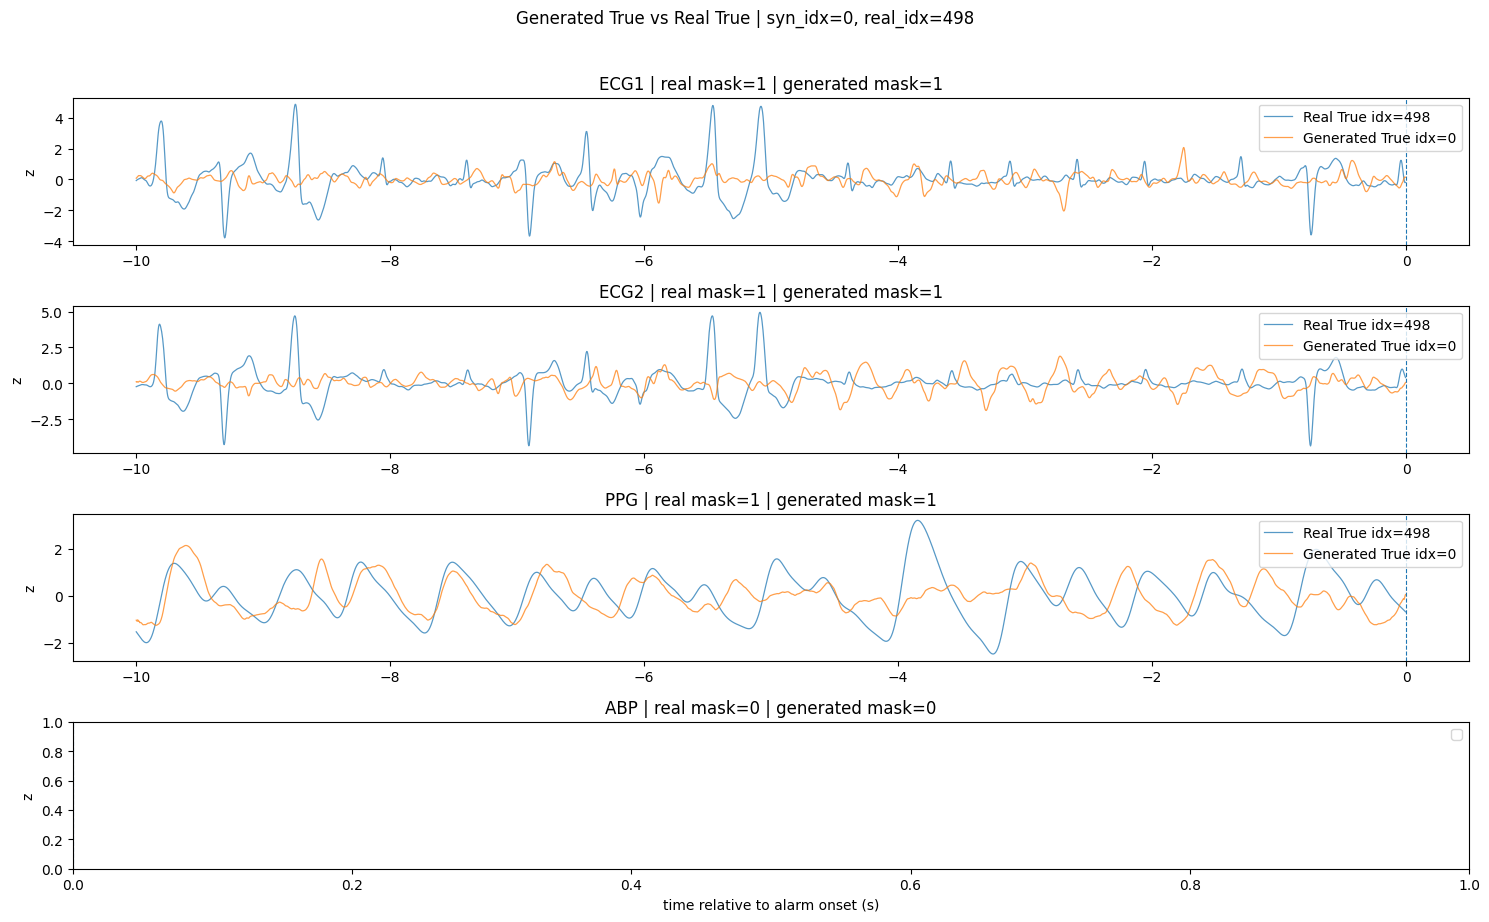

498

In [44]:
def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def pick_real_true_idx(y_real, m_real, target_mask=None, same_mask=True, seed=None):
    rng = np.random.default_rng(seed)

    y_np = _to_numpy(y_real)
    m_np = _to_numpy(m_real).astype(int)

    true_idx = np.where(y_np == 1)[0]

    if same_mask and target_mask is not None:
        target_mask = _to_numpy(target_mask).astype(int)

        matched = [
            idx for idx in true_idx
            if np.array_equal(m_np[idx], target_mask)
        ]

        if len(matched) > 0:
            return int(rng.choice(matched))

    return int(rng.choice(true_idx))


def plot_generated_vs_real_true(
    X_syn,
    m_syn,
    X_real,
    y_real,
    m_real,
    syn_idx=0,
    real_idx=None,
    same_mask=True,
    fs=250,
    channel_names=("ECG1", "ECG2", "PPG", "ABP"),
):
    x_syn = _to_numpy(X_syn[syn_idx])
    mask_syn = _to_numpy(m_syn[syn_idx]).astype(int)

    if real_idx is None:
        real_idx = pick_real_true_idx(
            y_real=y_real,
            m_real=m_real,
            target_mask=mask_syn,
            same_mask=same_mask,
        )

    x_real = _to_numpy(X_real[real_idx])
    mask_real = _to_numpy(m_real[real_idx]).astype(int)

    t = np.arange(x_syn.shape[1]) / fs - 10.0

    plt.figure(figsize=(15, 9))

    for i, ch in enumerate(channel_names):
        plt.subplot(4, 1, i + 1)

        if mask_real[i] == 1:
            plt.plot(
                t,
                x_real[i],
                linewidth=0.9,
                alpha=0.75,
                label=f"Real True idx={real_idx}",
            )

        if mask_syn[i] == 1:
            plt.plot(
                t,
                x_syn[i],
                linewidth=0.9,
                alpha=0.75,
                label=f"Generated True idx={syn_idx}",
            )

        plt.axvline(0, linestyle="--", linewidth=0.8)
        plt.title(f"{ch} | real mask={mask_real[i]} | generated mask={mask_syn[i]}")
        plt.ylabel("z")
        plt.legend(loc="upper right")

    plt.xlabel("time relative to alarm onset (s)")
    plt.suptitle(
        f"Generated True vs Real True | syn_idx={syn_idx}, real_idx={real_idx}",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    return real_idx


plot_generated_vs_real_true(
    X_syn=X_cvae_true,
    m_syn=m_cvae_true,
    X_real=X_train,
    y_real=y_train,
    m_real=m_train,
    syn_idx=0,
    same_mask=True,
)

In [45]:
@torch.no_grad()
def latent_diagnostics(model, X, y, m, n=512, device="cuda"):
    model.eval()

    true_idx = torch.where(y == 1)[0]
    idx = true_idx[torch.randperm(len(true_idx))[:n]]

    xb = X[idx].to(device).float()
    yb = y[idx].to(device).long()
    mb = m[idx].to(device).float()
    cb = torch.cat([yb.float().unsqueeze(1), mb], dim=1)

    mu, logvar = model.encode(xb, cb)
    std = torch.exp(0.5 * logvar)

    print("mu mean:", mu.mean().item())
    print("mu std :", mu.std().item())
    print("std mean:", std.mean().item())
    print("std std :", std.std().item())
    print("logvar mean:", logvar.mean().item())

latent_diagnostics(model, X_train, y_train, m_train, n=512, device=device)

mu mean: -0.0006660763174295425
mu std : 0.9591205716133118
std mean: 0.18351396918296814
std std : 0.04764248803257942
logvar mean: -3.4406046867370605
